In [ ]:
!pip install tensorflow matplotlib numpy


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense


In [ ]:
# Vocabulary size (top words only)
max_features = 10000
maxlen = 200  # each review cut/padded to 200 words

print("Loading data...")
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

print(len(x_train), "train sequences")
print(len(x_test), "test sequences")

# Pad sequences to fixed length
x_train = sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = sequence.pad_sequences(x_test, maxlen=maxlen)


Loading data...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
25000 train sequences
25000 test sequences


In [ ]:
# Vocabulary size (top words only)
max_features = 10000
maxlen = 200  # each review cut/padded to 200 words

print("Loading data...")
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

print(len(x_train), "train sequences")
print(len(x_test), "test sequences")

# Pad sequences to fixed length
x_train = sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = sequence.pad_sequences(x_test, maxlen=maxlen)


Loading data...
25000 train sequences
25000 test sequences


In [ ]:
model = Sequential()
model.add(Embedding(max_features, 128))        # word embeddings
model.add(SimpleRNN(128, dropout=0.2))         # Simple RNN
model.add(Dense(1, activation='sigmoid'))      # output layer (binary)

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

print(model.summary())


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
history = model.fit(x_train, y_train,
                    batch_size=32,
                    epochs=5,
                    validation_data=(x_test, y_test))


Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 98s 121ms/step - accuracy: 0.5384 - loss: 0.6872 - val_accuracy: 0.7583 - val_loss: 0.5289
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 88s 113ms/step - accuracy: 0.7564 - loss: 0.5167 - val_accuracy: 0.7844 - val_loss: 0.4991
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 88s 112ms/step - accuracy: 0.7911 - loss: 0.4540 - val_accuracy: 0.7668 - val_loss: 0.5078
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 89s 113ms/step - accuracy: 0.7864 - loss: 0.4592 - val_accuracy: 0.6814 - val_loss: 0.5928
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 141s 113ms/step - accuracy: 0.8269 - loss: 0.3926 - val_accuracy: 0.7569 - val_loss: 0.5137


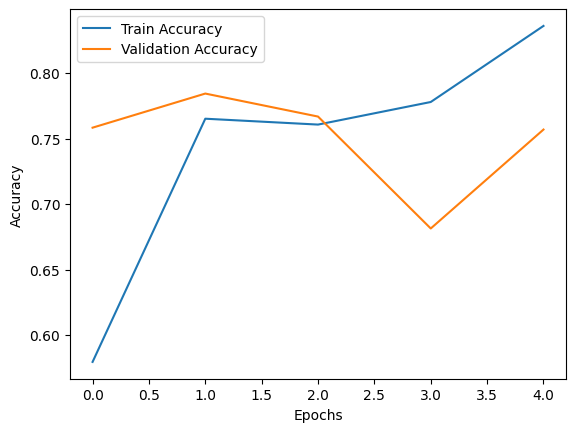

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [ ]:
import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence

# Load word index from IMDB
word_index = imdb.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

# Function to encode user review into integer sequence
def encode_review(text, word_index, maxlen=200):
    words = text.lower().split()
    encoded = []
    for word in words:
        index = word_index.get(word)
        if index is not None and index < 10000:  # keep only top words
            encoded.append(index + 3)  # +3 offset for reserved indices
        else:
            encoded.append(2)  # 2 = "unknown"
    return sequence.pad_sequences([encoded], maxlen=maxlen)

# ---- Take input from user ----
user_review = input("Enter your movie review: ")

# Preprocess the input review
processed_review = encode_review(user_review, word_index, maxlen=200)

# Predict sentiment
prediction = model.predict(processed_review)[0][0]

print("\nYour Review:", user_review)
print("Prediction:", "Positive 😀" if prediction > 0.5 else "Negative 😞")
print("Confidence Score:", prediction)


Enter your movie review: I sure would like to see a resurrection of a up dated Seahunt series with the tech they have today i...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

Your Review: I sure would like to see a resurrection of a up dated Seahunt series with the tech they have today i...
Prediction: Positive 😀
Confidence Score: 0.796815


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Train the model
history = model.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=5,
    validation_data=(x_test, y_test)
)

# Evaluate on test set
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy * 100:.2f}%")


Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 60s 152ms/step - accuracy: 0.8513 - loss: 0.3631 - val_accuracy: 0.7214 - val_loss: 0.5663
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 60s 153ms/step - accuracy: 0.8564 - loss: 0.3476 - val_accuracy: 0.7187 - val_loss: 0.5582
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 80s 149ms/step - accuracy: 0.8689 - loss: 0.3324 - val_accuracy: 0.7423 - val_loss: 0.5399
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 59s 151ms/step - accuracy: 0.8889 - loss: 0.2782 - val_accuracy: 0.8182 - val_loss: 0.4926
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 58s 150ms/step - accuracy: 0.9123 - loss: 0.2340 - val_accuracy: 0.7985 - val_loss: 0.5306
Test Accuracy: 79.85%


In [ ]:
'''
!pip install tensorflow matplotlib numpy
! → Tells Jupyter Notebook or Google Colab to run a shell command.

pip install → Python package manager command to download and install packages.

tensorflow → Installs the TensorFlow library (for deep learning).

matplotlib → Installs Matplotlib (for plotting graphs, images, curves).

numpy → Installs NumPy (for numerical computations and array operations).

✅ 1. Import Libraries
import numpy as np
import matplotlib.pyplot as plt


numpy → for numerical operations, arrays

matplotlib.pyplot → for plotting graphs, visualizations

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense


imdb → preloaded dataset of 50,000 movie reviews for sentiment analysis

sequence → tools to preprocess sequences (e.g., padding)

Sequential → Keras model API (stack layers sequentially)

Embedding → converts word indices into dense vectors

SimpleRNN → basic recurrent neural network layer

Dense → fully connected layer

✅ 2. Set Parameters
max_features = 10000


Only consider the top 10,000 most frequent words

Less frequent words are ignored

maxlen = 200  # each review cut/padded to 200 words


Each review is either cut or padded to 200 words

RNNs require same input length for batch processing

✅ 3. Load IMDB Dataset
print("Loading data...")
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)


Downloads IMDB dataset (if not already available)

Returns integer sequences, where each number represents a word

num_words=max_features → only keep the most frequent 10,000 words

✅ 4. Check Dataset Size
print(len(x_train), "train sequences")
print(len(x_test), "test sequences")


Prints number of training and testing samples

IMDB dataset has 25,000 train and 25,000 test reviews

✅ 5. Pad Sequences
x_train = sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = sequence.pad_sequences(x_test, maxlen=maxlen)


pad_sequences → ensures all sequences are exactly 200 words long

Short reviews → padded with 0 at the start

Long reviews → truncated to 200 words

Why: RNNs require fixed-length input sequences for batch training.

🎯 Summary
Step	Purpose
max_features=10000	Keep top 10k words
maxlen=200	Fix sequence length for RNN
imdb.load_data	Load integer-encoded IMDB reviews
pad_sequences	Pad/truncate reviews to same length


✅ 1. Create Sequential Model
model = Sequential()


Initializes a Sequential model in Keras

Layers are added one after another

✅ 2. Embedding Layer
model.add(Embedding(max_features, 128))  # word embeddings


Embedding layer maps each word index (integer) to a 128-dimensional vector

Input: integers (word indices 0–9999)

Output: dense vectors of size 128 for each word

Learns a meaningful representation of words during training

Shape of output: (batch_size, sequence_length, 128)

✅ 3. SimpleRNN Layer
model.add(SimpleRNN(128, dropout=0.2))  # Simple RNN


SimpleRNN → basic recurrent neural network

128 units → size of the hidden state

dropout=0.2 → randomly ignores 20% of inputs to prevent overfitting

Purpose: processes the sequence of word embeddings step by step, capturing temporal dependencies in the text

Output shape: (batch_size, 128) → last hidden state

✅ 4. Dense Output Layer
model.add(Dense(1, activation='sigmoid'))  # output layer (binary)


Fully connected layer with 1 neuron

Activation = sigmoid → outputs a probability between 0 and 1

Purpose: predicts binary sentiment (0 = negative, 1 = positive)

✅ 5. Compile Model
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])


loss='binary_crossentropy' → suitable for binary classification

optimizer='adam' → Adam optimizer, adapts learning rate

metrics=['accuracy'] → track training accuracy

✅ 6. Summary
print(model.summary())


Prints the model architecture

Shows layer types, output shapes, and number of parameters

Example output:

Layer	Output Shape	#Params
Embedding	(None, 200, 128)	1,280,000
SimpleRNN	(None, 128)	33,024
Dense	(None, 1)	129
🎯 Conceptual Flow

Input: integer-encoded review of length 200

Embedding: convert integers → 128-dim vectors

SimpleRNN: process sequence → hidden state captures context

Dense(sigmoid): predict positive/negative sentiment

If you want, I can also write the full training code with model.fit() and plot the accuracy/loss curves for this RNN on the IMDB dataset.

✅ 1. Train the Model
history = model.fit(x_train, y_train,
                    batch_size=32,
                    epochs=5,
                    validation_data=(x_test, y_test))

Explanation of Parameters

x_train, y_train

Training data: padded sequences of reviews (x_train) and corresponding binary labels (y_train).

batch_size=32

Number of samples processed before updating model weights.

Smaller batch → more updates per epoch, can improve generalization, but slower.

epochs=5

Number of complete passes through the training dataset.

Each epoch allows the model to adjust weights and improve performance.

validation_data=(x_test, y_test)

Evaluates the model on unseen test data after each epoch.

Reports validation loss and accuracy.

history

Stores training metrics (loss, accuracy, validation loss, validation accuracy) for plotting or analysis later.

✅ 2. What Happens During Training

For each batch of 32 reviews:

Model computes predictions using forward pass.

Loss (binary_crossentropy) is calculated.

Backpropagation updates the weights.

After all batches → 1 epoch completed.

After each epoch, validation metrics are calculated.

plt.plot(history.history['accuracy'], label='Train Accuracy')
Plots training accuracy over epochs.

history.history['accuracy'] → list of accuracy values for each epoch during training.

label='Train Accuracy' → legend label for this line.

python
Copy code
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
Plots validation accuracy over epochs.

history.history['val_accuracy'] → list of accuracy values on validation (test) data.

label='Validation Accuracy' → legend label for this line.

python
Copy code
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
Adds x-axis label → “Epochs”

Adds y-axis label → “Accuracy” (0 to 1 scale)

python
Copy code
plt.legend()
Displays the legend so you can distinguish training and validation curves.

python
Copy code
plt.show()
Renders the plot and displays it.

✅ Purpose
This plot shows how training accuracy and validation accuracy evolve over epochs.

You can use it to detect overfitting or underfitting:

If training accuracy ↑ but validation accuracy stagnates or ↓ → overfitting

If both are low → underfitting

✅ 1. Import Libraries
import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence


numpy → array operations

imdb → preloaded IMDB dataset and word index

sequence → functions for padding/truncating sequences

✅ 2. Load Word Index
word_index = imdb.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}


word_index → maps words to integer indices (e.g., 'movie': 15)

reverse_word_index → maps indices → words (useful for decoding sequences)

✅ 3. Encode Review Function
def encode_review(text, word_index, maxlen=200):
    words = text.lower().split()
    encoded = []
    for word in words:
        index = word_index.get(word)
        if index is not None and index < 10000:  # keep only top words
            encoded.append(index + 3)  # +3 offset for reserved indices
        else:
            encoded.append(2)  # 2 = "unknown"
    return sequence.pad_sequences([encoded], maxlen=maxlen)


Step-by-step:

Convert review to lowercase and split into words.

For each word:

Look up its integer index in word_index.

Keep only top 10,000 words.

Add +3 offset because Keras reserves:

0 → padding

1 → start of sequence

2 → unknown

If word not found, assign 2 → unknown word.

Pad the sequence to maxlen=200 for RNN input.

✅ 4. Take User Input
user_review = input("Enter your movie review: ")


Prompts the user to type a review.

Example: "I loved the movie, it was fantastic!"

✅ 5. Preprocess Input Review
processed_review = encode_review(user_review, word_index, maxlen=200)


Converts the text review → integer sequence

Pads/truncates to 200 words so the RNN can process it

✅ 6. Make Prediction
prediction = model.predict(processed_review)[0][0]


model.predict() → returns probability for positive sentiment

[0][0] → extract the scalar from the returned array

✅ 7. Print Result
print("\nYour Review:", user_review)
print("Prediction:", "Positive 😀" if prediction > 0.5 else "Negative 😞")
print("Confidence Score:", prediction)


Displays original review

Predicts Positive if probability > 0.5, else Negative

Shows confidence score between 0 and 1

🎯 Example Output
Enter your movie review: I loved the movie, it was amazing!
Your Review: I loved the movie, it was amazing!
Prediction: Positive 😀
Confidence Score: 0.8721

